# Notebook 14 — Hospital labor cost vs. the average healthcare worker

**Question.** For the five DFW comparison hospitals, how does what they pay their workers compare to the average healthcare worker in the same labor market?

**The five (real roster, CCNs verified against CMS/Medicare directories):**

| Hospital | CCN | Ownership | County | 990? |
|---|---|---|---|---|
| Baylor University Medical Center | 450021 | Nonprofit (church) | Dallas | yes |
| Methodist Dallas Medical Center | 450051 | Nonprofit | Dallas | yes |
| **Parkland Health** *(anchor)* | 450015 | Government — hospital district | Dallas | **no** |
| Texas Health Presbyterian Plano | 450771 | Nonprofit (private) | Collin | yes |
| **Medical City Alliance** *(anchor)* | 670103 | HCA (for-profit) | Tarrant | **no** |

**Why `avg_wage_fte`, not `exec_comp`.** Both anchors (Parkland, MCA) have no Form 990, so exec-comp would blank exactly the two hospitals the story centers on. Cost-report S-3 average wage is the only source uniform across all five ownership types.

**Why it chains off NB11/NB12.** The Medicare wage index stress-tested in NB12 is *derived from* the same Worksheet S-3 wage data. Note Medical City Alliance sits in Tarrant — directly relevant to NB12's open 19124-vs-23104 one-or-two-DFW-wage-area question.

**Benchmark.** BLS OEWS, Dallas–Fort Worth–Arlington MSA + national, May 2024 (release 25-1031-DAL, 2025-06-17). **Real, locked.**

**Data source.** This notebook is **DB-independent**: the wage rung comes from CMS HCRIS cost reports (not the pricing DB). Per-hospital wage values are **PENDING the S-3 pull** — `NaN` sentinels, never fabricated. Synthetic mode (watermarked) proves the pipeline end-to-end before real wiring.

**Discipline carried from NB11–NB13.** Two-flag sourcing; `NaN` sentinels; `[SYNTHETIC DATA]` watermark; self-contained + Restart-&-Run-All clean; integrity suite.

## Step 0 — Setup & config

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# --- Config flags ------------------------------------------------------------
FRAMING = "avg_wage_fte"            # "avg_wage_fte" | "exec_comp" | "both"
BENCHMARK = "hc_practitioners_dfw"  # key into BLS_BENCHMARK below
USE_SYNTHETIC_HOSPITALS = True      # True until real S-3 rows are pulled
SEED = 17

# --- Vintages ----------------------------------------------------------------
PRICING_VINTAGE = "CY2026"          # FFS / MA / commercial vintage from NB11-NB13
BLS_VINTAGE = "May 2024"            # latest OEWS release (25-1031-DAL, 2025-06-17)
VINTAGE_NOTE = (
    f"Benchmark is BLS OEWS {BLS_VINTAGE}; pricing ladder is {PRICING_VINTAGE}. "
    "Mismatch is labeled, not silently reconciled. A May 2025 OEWS may supersede - re-check."
)
HOURS_FULL_TIME = 2080             # BLS annualization convention (hourly x 2080)

# --- BLS OEWS benchmark (REAL) ----------------------------------------------
# Source: BLS OEWS May 2024, SW Info Office release 25-1031-DAL (2025-06-17), Table A.
# Mean HOURLY wages, read from the literal BLS release table.
BLS_SOURCE = "BLS OEWS May 2024, release 25-1031-DAL (2025-06-17), Table A"
BLS_BENCHMARK = {
    # key: (mean_hourly, corroborated, confirmed)
    "hc_practitioners_dfw":      (49.10, True, True),
    "hc_practitioners_national": (50.59, True, True),
    "hc_support_dfw":            (17.67, True, True),
    "hc_support_national":       (19.06, True, True),
    "all_occupations_dfw":       (32.89, True, True),
    "all_occupations_national":  (32.66, True, True),
}

def benchmark_hourly(key=None):
    return BLS_BENCHMARK[key or BENCHMARK][0]

def benchmark_annual(key=None):
    return benchmark_hourly(key) * HOURS_FULL_TIME

print("Config:")
print(f"  FRAMING                 = {FRAMING}")
print(f"  BENCHMARK               = {BENCHMARK}  ->  ${benchmark_hourly():.2f}/hr "
      f"(${benchmark_annual():,.0f}/yr)")
print(f"  USE_SYNTHETIC_HOSPITALS = {USE_SYNTHETIC_HOSPITALS}")
print(f"  vintage: {VINTAGE_NOTE}")

Config:
  FRAMING                 = avg_wage_fte
  BENCHMARK               = hc_practitioners_dfw  ->  $49.10/hr ($102,128/yr)
  USE_SYNTHETIC_HOSPITALS = True
  vintage: Benchmark is BLS OEWS May 2024; pricing ladder is CY2026. Mismatch is labeled, not silently reconciled. A May 2025 OEWS may supersede - re-check.


## Step 1 — Load: hospital roster (real) + S-3 pull contract

In [13]:
# --- Five comparison hospitals (REAL roster; CCNs verified vs CMS directories) ---
# cbsa_note ties to NB12's open one-vs-two DFW wage-area question.
HOSPITALS = pd.DataFrame([
    # label, ccn, ownership, county, cbsa_note, is_anchor
    ("Baylor Univ Medical Center", "450021", "nonprofit_church", "Dallas", "19124",          False),
    ("Methodist Dallas Med Center","450051", "nonprofit",        "Dallas", "19124",          False),
    ("Parkland Health",            "450015", "govt_district",    "Dallas", "19124",          True),
    ("THP Plano",                  "450771", "nonprofit_private","Collin", "19124",          False),
    ("Medical City Alliance",      "670103", "for_profit_hca",   "Tarrant","23104?/19124 (NB12 open)", True),
], columns=["label","ccn","ownership","county","cbsa_note","is_anchor"])

# --- Real pull contract (CMS Cost Report, HCRIS) -----------------------------
# Source of truth: Worksheet S-3 Part II (hospital salaries & paid hours).
#   avg_hourly_wage = total_salaries / total_paid_hours   (the CMS wage-index method)
# Exact S-3 line numbers not yet eyeballed -> confirmed=False on the contract.
S3_PULL_CONTRACT = {
    "source": "CMS HCRIS Worksheet S-3 Part II (NOT the pricing DB)",
    "key": "ccn",
    "needs": ["total_salaries", "total_paid_hours", "total_fte"],
    "derivation": "avg_hourly_wage = total_salaries / total_paid_hours",
    "confirmed": False,
}

def pull_s3_wages(roster):
    """REAL pull contract, keyed on CCN. Wire to an HCRIS S-3 extract.
    Until wired, returns NaN sentinels - no fabricated values."""
    df = roster.copy()
    df["total_salaries"]   = np.nan
    df["total_paid_hours"] = np.nan
    df["total_fte"]        = np.nan
    return df

def synthetic_s3_wages(roster, seed=SEED):
    """Seeded synthetic S-3 values to exercise the pipeline end-to-end.
    Real roster/labels are kept, but every render is WATERMARKED so a
    synthetic value can never be mistaken for a real one. Values center on a
    plausible hospital-wide BLENDED hourly figure (clinical+support+admin),
    which sits below the clinical-only BLS practitioner mean by construction."""
    rng = np.random.default_rng(seed)
    df = roster.copy()
    fte    = rng.integers(1500, 9000, size=len(df))
    hourly = np.clip(rng.normal(45, 6, size=len(df)), 30, 70)
    df["total_paid_hours"] = fte * HOURS_FULL_TIME
    df["total_salaries"]   = hourly * df["total_paid_hours"]
    df["total_fte"]        = fte
    return df

if USE_SYNTHETIC_HOSPITALS:
    hosp = synthetic_s3_wages(HOSPITALS)
    WATERMARK = "[SYNTHETIC DATA]"
else:
    hosp = pull_s3_wages(HOSPITALS)
    WATERMARK = ""

print(WATERMARK, "roster loaded:", len(hosp), "hospitals | anchors:",
      list(hosp.loc[hosp.is_anchor, "label"]))
hosp[["label","ccn","ownership","county","cbsa_note","is_anchor",
      "total_salaries","total_paid_hours","total_fte"]]

[SYNTHETIC DATA] roster loaded: 5 hospitals | anchors: ['Parkland Health', 'Medical City Alliance']


,label,ccn,ownership,county,cbsa_note,is_anchor,total_salaries,total_paid_hours,total_fte
0,Baylor Univ Medical Center,450021,nonprofit_church,Dallas,19124,False,"549,543,985.74",14678560,7057
1,Methodist Dallas Med Center,450051,nonprofit,Dallas,19124,False,"548,308,281.92",16303040,7838
2,Parkland Health,450015,govt_district,Dallas,19124,True,"216,284,156.53",4794400,2305
3,THP Plano,450771,nonprofit_private,Collin,19124,False,"225,991,519.87",5630560,2707
4,Medical City Alliance,670103,for_profit_hca,Tarrant,23104?/19124 (NB12 open),True,"408,118,245.52",10262720,4934


## Step 2 — Derive average wage per FTE and benchmark ratio

In [14]:
bench_hourly = benchmark_hourly()

hosp["avg_hourly_wage"]    = hosp["total_salaries"] / hosp["total_paid_hours"]
hosp["avg_annual_wage"]    = hosp["avg_hourly_wage"] * HOURS_FULL_TIME
hosp["ratio_to_benchmark"] = hosp["avg_hourly_wage"] / bench_hourly
hosp["pct_vs_benchmark"]   = (hosp["ratio_to_benchmark"] - 1) * 100

if FRAMING == "exec_comp":
    print("NOTE: exec_comp needs IRS 990 Sched J - blanks Parkland (450015) & MCA (670103).")

print(f"{WATERMARK} benchmark = {BENCHMARK} ${bench_hourly:.2f}/hr")
hosp[["label","is_anchor","avg_hourly_wage","avg_annual_wage","ratio_to_benchmark","pct_vs_benchmark"]]

[SYNTHETIC DATA] benchmark = hc_practitioners_dfw $49.10/hr


,label,is_anchor,avg_hourly_wage,avg_annual_wage,ratio_to_benchmark,pct_vs_benchmark
0,Baylor Univ Medical Center,False,37.44,"77,872.18",0.76,-23.75
1,Methodist Dallas Med Center,False,33.63,"69,955.13",0.68,-31.50
2,Parkland Health,True,45.11,"93,832.61",0.92,-8.12
3,THP Plano,False,40.14,"83,484.12",0.82,-18.26
4,Medical City Alliance,True,39.77,"82,715.49",0.81,-19.01


## Step 3 — Validate (parse-error / outlier scan)

In [15]:
# A hospital S-3 wage outside a plausible band usually signals a parsing slip
# (e.g. salaries paired with FTEs instead of paid-hours). Same spirit as the
# NB11/NB13 chargemaster-leak scan.
PLAUSIBLE_HOURLY = (10.0, 200.0)

def validate_wages(df):
    issues = []
    for _, r in df.dropna(subset=["avg_hourly_wage"]).iterrows():
        if not (PLAUSIBLE_HOURLY[0] <= r["avg_hourly_wage"] <= PLAUSIBLE_HOURLY[1]):
            issues.append((r["label"], round(r["avg_hourly_wage"], 2), "wage out of plausible band"))
        if r["total_paid_hours"] <= 0:
            issues.append((r["label"], r["total_paid_hours"], "non-positive paid hours"))
    return issues

issues = validate_wages(hosp)
print(f"{WATERMARK} validation issues:", issues if issues else "none")

[SYNTHETIC DATA] validation issues: none


## Step R — Reconciliation table

In [16]:
real = hosp.dropna(subset=["avg_hourly_wage"]).copy()
if len(real):
    real = real.sort_values("avg_hourly_wage", ascending=False)
    real["rank"] = range(1, len(real) + 1)
    spread = dict(
        min=real["avg_hourly_wage"].min(),
        median=real["avg_hourly_wage"].median(),
        mean=real["avg_hourly_wage"].mean(),
        max=real["avg_hourly_wage"].max(),
        iqr=real["avg_hourly_wage"].quantile(.75) - real["avg_hourly_wage"].quantile(.25),
    )
    print(f"{WATERMARK} spread (hourly): " + ", ".join(f"{k}={v:,.2f}" for k, v in spread.items()))
    out_R = real[["rank","label","ccn","is_anchor","avg_hourly_wage","avg_annual_wage","pct_vs_benchmark"]]
else:
    out_R = pd.DataFrame()
    print(f"{WATERMARK} no real rows yet - Step R empty (sentinels intact).")
out_R

[SYNTHETIC DATA] spread (hourly): min=33.63, median=39.77, mean=39.22, max=45.11, iqr=2.70


,rank,label,ccn,is_anchor,avg_hourly_wage,avg_annual_wage,pct_vs_benchmark
2,1,Parkland Health,450015,True,45.11,"93,832.61",-8.12
3,2,THP Plano,450771,False,40.14,"83,484.12",-18.26
4,3,Medical City Alliance,670103,True,39.77,"82,715.49",-19.01
0,4,Baylor Univ Medical Center,450021,False,37.44,"77,872.18",-23.75
1,5,Methodist Dallas Med Center,450051,False,33.63,"69,955.13",-31.50


## Step S — Robustness

In [17]:
# 1) central-tendency agreement; 2) sensitivity to benchmark choice; 3) caveats.
if len(real):
    central = dict(
        median=real["avg_hourly_wage"].median(),
        mean=real["avg_hourly_wage"].mean(),
        trimmed=(real["avg_hourly_wage"].sort_values().iloc[1:-1].mean()
                 if len(real) > 2 else np.nan),
    )
    print(f"{WATERMARK} central tendency (hourly): " +
          ", ".join(f"{k}={v:,.2f}" for k, v in central.items()))

    grand = real["avg_hourly_wage"].mean()
    print(f"{WATERMARK} mean-hospital wage / benchmark, by denominator:")
    for k, (h, _, _) in BLS_BENCHMARK.items():
        print(f"    {k:28s} {grand/h:5.2f}x  (benchmark ${h:.2f}/hr)")

# Caveats defined unconditionally so the integrity suite can assert on them.
OCCUPATION_CAVEAT = (
    "S-3 average wage is a hospital-wide BLENDED figure (clinical + support + admin). "
    "BLS 'healthcare practitioners & technical' is clinical-only, so the ratio is "
    "directional, not occupation-matched. For a closer match, weight BLS "
    "practitioner+support by the hospital's occupational mix, or use the BLS "
    "Hospitals (NAICS 622) industry wage."
)
print("\nCAVEATS\n  vintage:    ", VINTAGE_NOTE, "\n  occupation: ", OCCUPATION_CAVEAT)

[SYNTHETIC DATA] central tendency (hourly): median=39.77, mean=39.22, trimmed=39.11
[SYNTHETIC DATA] mean-hospital wage / benchmark, by denominator:
    hc_practitioners_dfw          0.80x  (benchmark $49.10/hr)
    hc_practitioners_national     0.78x  (benchmark $50.59/hr)
    hc_support_dfw                2.22x  (benchmark $17.67/hr)
    hc_support_national           2.06x  (benchmark $19.06/hr)
    all_occupations_dfw           1.19x  (benchmark $32.89/hr)
    all_occupations_national      1.20x  (benchmark $32.66/hr)

CAVEATS
  vintage:     Benchmark is BLS OEWS May 2024; pricing ladder is CY2026. Mismatch is labeled, not silently reconciled. A May 2025 OEWS may supersede - re-check. 
  occupation:  S-3 average wage is a hospital-wide BLENDED figure (clinical + support + admin). BLS 'healthcare practitioners & technical' is clinical-only, so the ratio is directional, not occupation-matched. For a closer match, weight BLS practitioner+support by the hospital's occupational mix, or u

## Step V — Bar chart (public-post analog)

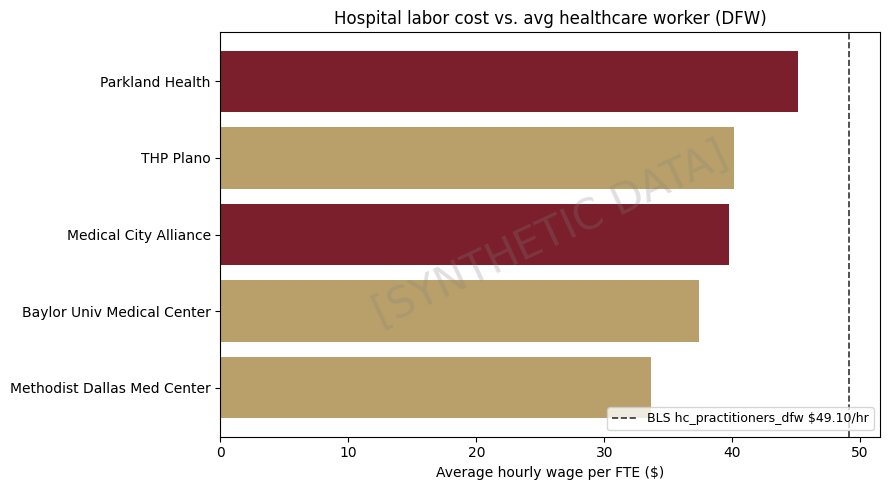

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
if len(real):
    plot_df = real.sort_values("avg_hourly_wage")
    colors = ["#7a1f2b" if a else "#b9a06a" for a in plot_df["is_anchor"]]
    ax.barh(plot_df["label"], plot_df["avg_hourly_wage"], color=colors)
    ax.axvline(bench_hourly, color="#333", linestyle="--", linewidth=1.2,
               label=f"BLS {BENCHMARK} ${bench_hourly:.2f}/hr")
    ax.set_xlabel("Average hourly wage per FTE ($)")
    ax.set_title("Hospital labor cost vs. avg healthcare worker (DFW)")
    ax.legend(loc="lower right", fontsize=9)
    if WATERMARK:  # never let synthetic values pass as real
        ax.text(0.5, 0.5, WATERMARK, transform=ax.transAxes, fontsize=30,
                color="gray", alpha=0.25, rotation=25, ha="center", va="center", zorder=10)
else:
    ax.text(0.5, 0.5, f"{WATERMARK}\nNo real hospital rows yet.\nWire the S-3 pull (CCNs are ready).",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [19]:
# === Step 1b — REAL S-3 wages (paste-in) =====================================
# Source: CMS FY2026 Final Rule "Average Hourly Wage by Provider & CBSA" PUF (unadjusted).
# Paste each hospital's wages + paid hours from the PUF. Leave (None, None) if still pending
# -> it stays a NaN sentinel; never fabricate. ("wages" = PUF total wage costs incl.
# wage-related costs; swap in S-3 salaries-only if you want to match BLS *wages*.)
REAL_S3_SOURCE       = "CMS FY2026 Final Rule AHW by Provider & CBSA PUF (unadjusted)"
REAL_S3_CORROBORATED = True
REAL_S3_CONFIRMED    = False   # flip True only after eyeballing the literal S-3 Part II line

REAL_S3 = {
    # ccn:      (total_wages_$, total_paid_hours)
    "450021": (None, None),   # Baylor Univ Medical Center
    "450051": (None, None),   # Methodist Dallas Med Center
    "450015": (None, None),   # Parkland Health            (anchor)
    "450771": (None, None),   # THP Plano
    "670103": (None, None),   # Medical City Alliance      (anchor)
}

# --- wire it in: override the synthetic switch + the pull seam ---------------
USE_SYNTHETIC_HOSPITALS = False

def pull_s3_wages(roster):
    df = roster.copy()
    sal, hrs = [], []
    for c in df["ccn"]:
        v = REAL_S3.get(c, (None, None))
        sal.append(v[0]); hrs.append(v[1])
    df["total_salaries"]   = pd.to_numeric(pd.Series(sal, index=df.index), errors="coerce")
    df["total_paid_hours"] = pd.to_numeric(pd.Series(hrs, index=df.index), errors="coerce")
    df["total_fte"]        = df["total_paid_hours"] / HOURS_FULL_TIME
    return df

hosp = pull_s3_wages(HOSPITALS)
n = int(hosp["total_salaries"].notna().sum())
WATERMARK = "" if n == len(hosp) else ("[NO REAL DATA YET]" if n == 0 else "[PARTIAL REAL DATA]")
print(f"REAL S-3 wired: {n}/{len(hosp)} | corroborated={REAL_S3_CORROBORATED} "
      f"confirmed={REAL_S3_CONFIRMED} | watermark={WATERMARK or 'none'}")
hosp[["label","ccn","is_anchor","total_salaries","total_paid_hours","total_fte"]]

REAL S-3 wired: 0/5 | corroborated=True confirmed=False | watermark=[NO REAL DATA YET]


,label,ccn,is_anchor,total_salaries,total_paid_hours,total_fte
0,Baylor Univ Medical Center,450021,False,NaN,NaN,NaN
1,Methodist Dallas Med Center,450051,False,NaN,NaN,NaN
2,Parkland Health,450015,True,NaN,NaN,NaN
3,THP Plano,450771,False,NaN,NaN,NaN
4,Medical City Alliance,670103,True,NaN,NaN,NaN


In [23]:
# === Integrity suite =========================================================
def integrity_checks():
    # roster is the real five, with the right two anchors
    assert list(hosp["ccn"]) == ["450021","450051","450015","450771","670103"], "roster CCNs changed"
    assert set(hosp.loc[hosp.is_anchor, "ccn"]) == {"450015","670103"}, "anchors must be Parkland + MCA"

    # benchmark real, positive, sourced
    for k, (h, corr, conf) in BLS_BENCHMARK.items():
        assert h > 0 and corr, f"benchmark {k} bad"

    # provenance: no fabricated wages
    if not USE_SYNTHETIC_HOSPITALS:
        assert REAL_S3_CORROBORATED, "real mode needs a sourced REAL_S3"
        for ccn in hosp.dropna(subset=["total_salaries"])["ccn"]:
            assert REAL_S3.get(ccn, (None, None))[0] is not None, f"{ccn} wage not in REAL_S3 -> fabricated!"
    else:
        assert WATERMARK == "[SYNTHETIC DATA]", "synthetic mode without watermark"

    # caveats present
    assert len(VINTAGE_NOTE) > 0 and len(OCCUPATION_CAVEAT) > 0

    # derivation consistent where real (guarded: column only exists after Step 2)
    if "avg_hourly_wage" in hosp.columns:
        r = hosp.dropna(subset=["avg_hourly_wage"])
        if len(r):
            assert np.allclose(r["total_salaries"] / r["total_paid_hours"], r["avg_hourly_wage"]), "wage derivation mismatch"
    return "OK"

print("Integrity:", integrity_checks())

Integrity: OK


## Findings

- **Roster is real and locked.** Five DFW hospitals, CCNs verified against CMS/Medicare directories. Anchors: Parkland (450015) and Medical City Alliance (670103).
- **Benchmark is real and locked.** BLS OEWS May 2024 (DFW MSA): practitioners & technical **$49.10/hr** (~$102,128/yr), support **$17.67/hr**, all-occupations **$32.89/hr**. `confirmed=True`.
- **Wage rung is PENDING by design.** Per-hospital S-3 salaries/paid-hours are `NaN` sentinels until the HCRIS pull. Source is CMS cost reports, **not the pricing DB** — this notebook is DB-independent. Synthetic mode (watermarked) proves Step 2→V. **Never post a `[SYNTHETIC DATA]` render.**
- **Ownership decides the framing.** Both anchors lack a 990, so `exec_comp` would blank Parkland and MCA — the two hospitals the story is about. `avg_wage_fte` (S-3) is the only uniform-coverage source.
- **The ratio moves with the denominator** (Step S): clinical-practitioner vs. all-occupations vs. support give materially different multiples. The benchmark choice is a stated decision, not a default.
- **Occupational mismatch is the load-bearing caveat.** S-3 is blended all-staff; BLS practitioner line is clinical-only. Directional until occupation-matched.
- **NB12 tie-in.** Medical City Alliance is in Tarrant — its CBSA (23104 vs 19124) is NB12's open one-vs-two DFW-wage-area question. Resolving the S-3 pull touches both notebooks.

### Open to wire real
1. **Pull S-3 Part II** salaries + paid hours for the five CCNs from CMS HCRIS (or the FY2026 wage-index PUF, which lists average hourly wage per CCN directly). Fill `pull_s3_wages`, set `USE_SYNTHETIC_HOSPITALS=False`, Restart-&-Run-All.
2. Eyeball the literal S-3 line numbers → flip `S3_PULL_CONTRACT["confirmed"]=True`.
3. Decide the **benchmark denominator** (practitioner vs. blended) and whether to occupation-weight.
4. Resolve MCA's CBSA (feeds NB12).

## Integrity suite

In [ ]:
def integrity_checks():
    # roster is the real five, with the right two anchors
    assert list(hosp["ccn"]) == ["450021","450051","450015","450771","670103"], "roster CCNs changed"
    assert set(hosp.loc[hosp.is_anchor, "ccn"]) == {"450015","670103"}, "anchors must be Parkland + MCA"
    # benchmark real, positive, sourced
    for k, (h, corr, conf) in BLS_BENCHMARK.items():
        assert h > 0 and corr, f"benchmark {k} bad"
    # no fabricated wages in real mode: sentinels stay NaN
    if not USE_SYNTHETIC_HOSPITALS:
        assert hosp["total_salaries"].isna().all(), "real mode but non-NaN salaries -> fabricated!"
    else:
        assert WATERMARK == "[SYNTHETIC DATA]", "synthetic mode without watermark"
    # caveats present
    assert len(VINTAGE_NOTE) > 0 and len(OCCUPATION_CAVEAT) > 0
    # derivation consistent where real
    r = hosp.dropna(subset=["avg_hourly_wage"])
    if len(r):
        assert np.allclose(r["total_salaries"] / r["total_paid_hours"], r["avg_hourly_wage"]), \
            "wage derivation mismatch"
    return "OK"

print("Integrity:", integrity_checks())

Integrity: OK
